In [ ]:
import pandas as pd 
a=pd.read_csv("The_Cancer_data_1500_V2.csv")
a

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
0,58,1,16.085313,0,1,8.146251,4.148219,1,1
1,71,0,30.828784,0,1,9.361630,3.519683,0,0
2,48,1,38.785084,0,2,5.135179,4.728368,0,1
3,34,0,30.040296,0,0,9.502792,2.044636,0,0
4,62,1,35.479721,0,0,5.356890,3.309849,0,1
...,...,...,...,...,...,...,...,...,...
1495,62,1,25.090025,0,0,9.892167,1.284158,0,1
1496,31,0,33.447125,0,1,1.668297,2.280636,1,1
1497,63,1,32.613861,1,1,0.466848,0.150101,0,1
1498,55,0,25.568216,0,0,7.795317,1.986138,1,1


In [2]:
a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1500 non-null   int64  
 1   Gender            1500 non-null   int64  
 2   BMI               1500 non-null   float64
 3   Smoking           1500 non-null   int64  
 4   GeneticRisk       1500 non-null   int64  
 5   PhysicalActivity  1500 non-null   float64
 6   AlcoholIntake     1500 non-null   float64
 7   CancerHistory     1500 non-null   int64  
 8   Diagnosis         1500 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 105.6 KB


In [3]:
x=a.iloc[:,:-1]
y=a.iloc[:,-1]

In [4]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

c:\Users\sinha\anaconda3\envs\ENV1\Lib\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.2)
  from scipy.sparse import csr_matrix, issparse


In [5]:
from sklearn.preprocessing import StandardScaler
st=StandardScaler()
x_train=st.fit_transform(x_train)
x_test=st.transform(x_test)

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.tree import plot_tree

In [7]:
dec=DecisionTreeClassifier(max_depth=44,criterion="log_loss")
dec.fit(x_train,y_train)
dec.score(x_test,y_test)

0.88

In [8]:
import pickle

pickle.dump(dec,open('Dec_model.pkl','wb'))

[Text(0.7399507261410788, 0.9642857142857143, 'x[7] <= 1.028\nlog_loss = 0.949\nsamples = 1200\nvalue = [759.0, 441.0]'),
 Text(0.5442168049792531, 0.8928571428571429, 'x[4] <= 1.482\nlog_loss = 0.87\nsamples = 1030\nvalue = [730, 300]'),
 Text(0.6420837655601659, 0.9285714285714286, 'True  '),
 Text(0.3125, 0.8214285714285714, 'x[1] <= 0.013\nlog_loss = 0.776\nsamples = 922\nvalue = [711, 211]'),
 Text(0.11203319502074689, 0.75, 'x[2] <= -0.058\nlog_loss = 0.485\nsamples = 466\nvalue = [417, 49]'),
 Text(0.03319502074688797, 0.6785714285714286, 'x[6] <= 0.817\nlog_loss = 0.182\nsamples = 218\nvalue = [212, 6]'),
 Text(0.016597510373443983, 0.6071428571428571, 'x[5] <= 0.536\nlog_loss = 0.094\nsamples = 167\nvalue = [165, 2]'),
 Text(0.008298755186721992, 0.5357142857142857, 'log_loss = 0.0\nsamples = 108\nvalue = [108, 0]'),
 Text(0.024896265560165973, 0.5357142857142857, 'x[5] <= 0.563\nlog_loss = 0.214\nsamples = 59\nvalue = [57, 2]'),
 Text(0.016597510373443983, 0.4642857142857143,

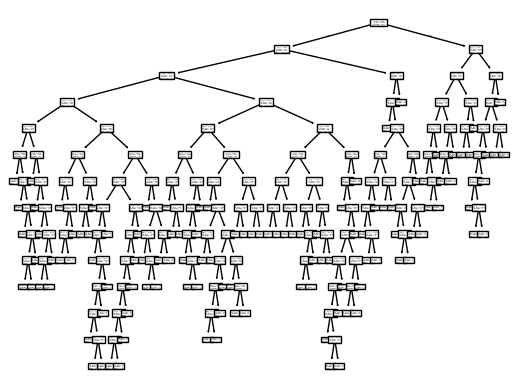

In [9]:
plot_tree(dec)

In [10]:
a.keys()

Index(['Age', 'Gender', 'BMI', 'Smoking', 'GeneticRisk', 'PhysicalActivity',
       'AlcoholIntake', 'CancerHistory', 'Diagnosis'],
      dtype='object')

In [ ]:
import streamlit as st

st.title("Cancer Prediction Web App")
st.write(
    "This is a simple web app to predict Cancer based on symptoms and demographics"
)

st.sidebar.title("Input Features")
Age = st.sidebar.slider(
    "Age",
    int(a["Age"].min()),
    int(a["Age"].max()),
)
Gender = st.sidebar.slider(
    "Gender",
    float(a["Gender"].min()),
    float(a["Gender"].max()),
)
# etc.

BMI = st.sidebar.slider(
    "BMI",
    float(a["BMI"].min()),
    float(a["BMI"].max()),
)
Smoking = st.sidebar.slider(
    "cough",
    float(a["Smoking"].min()),
    float(a["Smoking"].max()),
)

GeneticRisk = st.sidebar.slider(
    "city",
    float(a["GeneticRisk"].min()),
    float(a["GeneticRisk"].max()),
)
PhysicalActivity = st.sidebar.slider(
    "city",
    float(a["PhysicalActivity"].min()),
    float(a["PhysicalActivity"].max()),
)
AlcoholIntake = st.sidebar.slider(
    "city",
    float(a["AlcoholIntake"].min()),
    float(a["AlcoholIntake"].max()),
)
CancerHistory = st.sidebar.slider(
    "city",
    float(a["CancerHistory"].min()),
    float(a["CancerHistory"].max()),
)

input_data = [
    [
       Age, Gender, BMI, Smoking, GeneticRisk, PhysicalActivity,
       AlcoholIntake, CancerHistory,
    ]
]
prediction = dec.predict(input_data)
target_name = ["Has Cancer", "No Cancer"]
predicted_species = target_name[prediction[0]]


st.write("Prediction")
st.write(f"The predicted species is:====> {predicted_species}")

st.line_chart(a)
st.write(a)




2025-08-19 16:08:52.190 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-19 16:08:52.998 
  command:

    streamlit run c:\Users\sinha\anaconda3\envs\ENV1\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-08-19 16:08:52.999 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-19 16:08:53.000 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-19 16:08:53.002 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-19 16:08:53.003 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-19 16:08:53.003 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-19 16:08:53.003 Thread 'MainT